<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/ML_Pokemon_1_TheOptimizers_HawkesTsialasSchatzman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Data Hygiene

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = '/content/pokemons.csv'
pk_df = pd.read_csv(url)

pk_df.head()
pk_df = pk_df.drop_duplicates()
pk_df = pk_df.fillna('')

# add a column based on whether or not the rank is legendary
pk_df['is_legendary'] = pk_df['rank'] == 'legendary'

# Exploratory Data Analysis

In [ ]:
stats_df = pd.DataFrame(columns=["type", "mean", "median", "mode", "maximum", "minimum"])
# function get the stats of a dataframe
def get_stats(df, col):
  mean = df[col].mean()
  median = df[col].median()
  max = df[col].max()
  min = df[col].min()

  mode_series = df[col].mode()
  if not mode_series.empty:
    mode = mode_series[0]
  else:
    mode = "No Mode"

  return mean, median, mode, max, min

cols = ["hp", "atk", "def", "spatk", "spdef", "speed", "total", "height", "weight"]
for col in cols:
  mean, median, mode, max, min = get_stats(pk_df, col)
  stats_df.loc[len(stats_df)] = [col, mean, median, mode, max, min]

# dataframe with summarizing stats for the pokemon
stats_df.head(10)

,type,mean,median,mode,maximum,minimum
0,hp,70.184390,68.0,60,255,1
1,atk,77.521951,75.0,80,181,5
2,def,72.507317,70.0,60,230,5
3,spatk,70.080976,65.0,40,173,10
4,spdef,70.205854,67.0,50,230,20
5,speed,67.186341,65.0,50,200,5
6,total,427.686829,450.0,600,720,175
7,height,12.116098,10.0,6,200,1
8,weight,669.865366,280.0,10,9999,1


In [ ]:
# generation counts for the pokemon
gen_counts = pk_df["generation"].value_counts().sort_index()
print(gen_counts)

generation
generation-i       151
generation-ii      100
generation-iii     135
generation-iv      107
generation-ix      120
generation-v       156
generation-vi       72
generation-vii      88
generation-viii     96
Name: count, dtype: int64


In [ ]:
# type counts for the pokemon
type_counts = pk_df["type1"].value_counts().sort_index()
print(type_counts)

type1
bug          83
dark         45
dragon       37
electric     59
fairy        29
fighting     40
fire         66
flying        9
ghost        35
grass       103
ground       40
ice          31
normal      118
poison       42
psychic      60
rock         58
steel        36
water       134
Name: count, dtype: int64


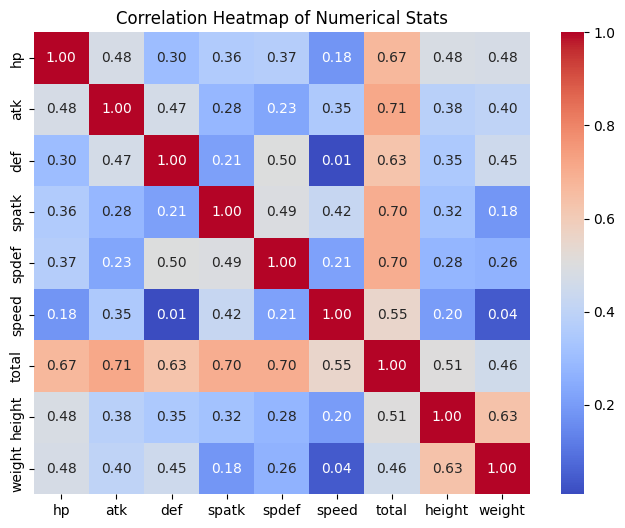

In [ ]:
# heatmap for each numerical stat in the dataframe
corr = pk_df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Numerical Stats")
plt.show()

In [ ]:
# dataframe that compares the stats of legendary and non-legendary pokemon
comp_stats = pk_df.groupby('is_legendary')[cols].agg(['mean','median', 'max', 'min']).T
comp_stats.head(20)

is_legendary       False       True 
hp    mean     68.341361   95.328571
      median   65.000000   91.000000
      max     255.000000  200.000000
      min       1.000000   43.000000
atk   mean     75.638743  103.214286
      median   73.000000  100.000000
      max     181.000000  160.000000
      min       5.000000   29.000000
def   mean     70.686911   97.342857
      median   65.000000   95.000000
      max     230.000000  200.000000
      min       5.000000   31.000000
spatk mean     67.712042  102.400000
      median   62.000000  100.000000
      max     173.000000  154.000000
      min      10.000000   29.000000
spdef mean     67.969634  100.714286
      median   65.000000   98.000000
      max     230.000000  200.000000
      min      20.000000   31.000000

# Feature Engineering

In [ ]:
# three features added

# survivability is based on the defense, special defense, and health of a pokemon
pk_df["survivability_index"] = pk_df['def']+pk_df['hp']+pk_df['spdef']

# balance is based on the standard deviation of a pokemons stats
# high values means stats are spread apart therefore a pokemon is specialized
# low values means stats are close together therefore a pokemon is balanced
pk_df["balance_index"] = pk_df[cols].std(axis=1)

# offense is based on attack, special attack, and speed values
pk_df["offensive_index"] = pk_df['atk'] + pk_df['spatk']
pk_df.head(5)

,id,name,rank,generation,evolves_from,type1,type2,hp,atk,def,...,speed,total,height,weight,abilities,desc,is_legendary,survivability_index,balance_index,offensive_index
0,1,bulbasaur,ordinary,generation-i,nothing,grass,poison,45,49,49,...,45,318,7,69,overgrow chlorophyll,A strange seed was planted on its back at birt...,False,159,91.452781,114
1,2,ivysaur,ordinary,generation-i,bulbasaur,grass,poison,60,62,63,...,60,405,10,130,overgrow chlorophyll,"When the bulb on its back grows large, it appe...",False,203,116.490462,142
2,3,venusaur,ordinary,generation-i,ivysaur,grass,poison,80,82,83,...,80,525,20,1000,overgrow chlorophyll,The plant blooms when it is absorbing solar en...,False,263,325.257206,182
3,4,charmander,ordinary,generation-i,nothing,fire,,39,52,43,...,65,309,6,85,blaze solar-power,"Obviously prefers hot places. When it rains, s...",False,132,88.943490,112
4,5,charmeleon,ordinary,generation-i,charmander,fire,,58,64,58,...,80,405,11,190,blaze solar-power,"When it swings its burning tail, it elevates t...",False,181,119.648443,144


# Visual Analytics

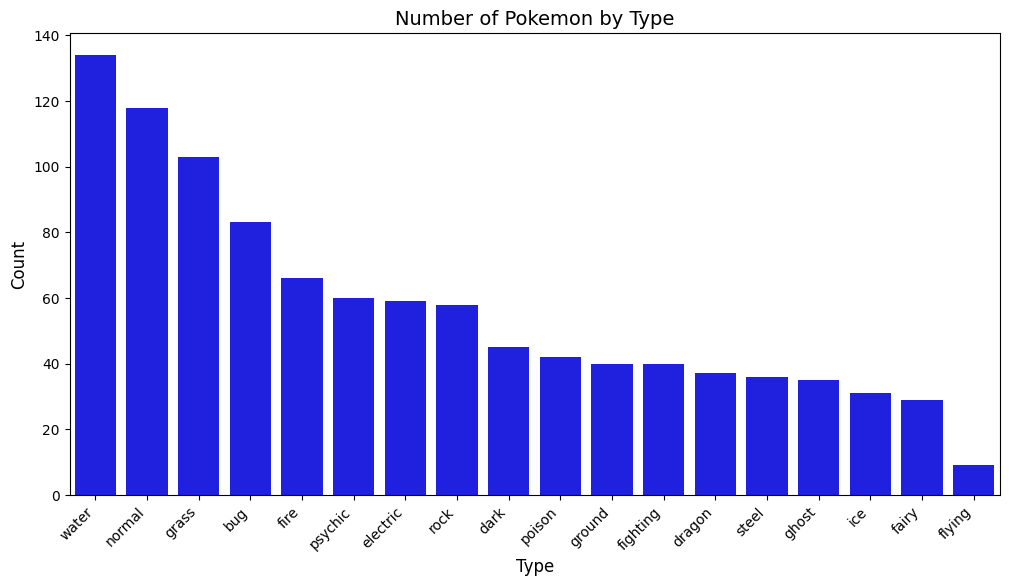

In [ ]:
# count pokemon by primary type
# determine the most and least type of pokemon
type_counts = pk_df['type1'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

plt.figure(figsize=(12,6))
sns.barplot(data=type_counts, x='type', y='count', color='blue')

plt.title("Number of Pokemon by Type", fontsize=14)
plt.xlabel("Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

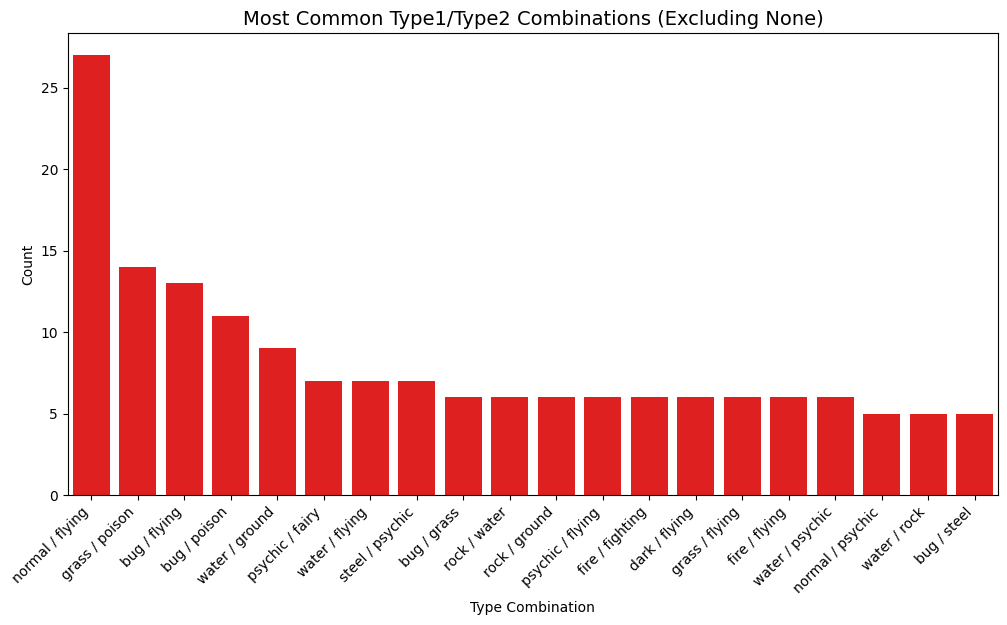

In [ ]:
# filter out rows where type2 is None
pk_df['type2'] = pk_df['type2'].replace({None: 'None', '': 'None'}).fillna('None').astype(str)
df_combo = pk_df[pk_df['type2'] != 'None'].copy()

# create a combined string for the type pair
df_combo['type_pair'] = df_combo['type1'] + " / " + df_combo['type2']

# plot top 20 most common combinations of types
# does not include cases where type2 is none
# determines what combinations are often seen together
top_combos = df_combo['type_pair'].value_counts().head(20).reset_index()
top_combos.columns = ['type_pair', 'count']

plt.figure(figsize=(12,6))
sns.barplot(data=top_combos, x='type_pair', y='count', color='red')
plt.xticks(rotation=45, ha='right')
plt.title("Most Common Type1/Type2 Combinations (Excluding None)", fontsize=14)
plt.xlabel("Type Combination")
plt.ylabel("Count")
plt.show()

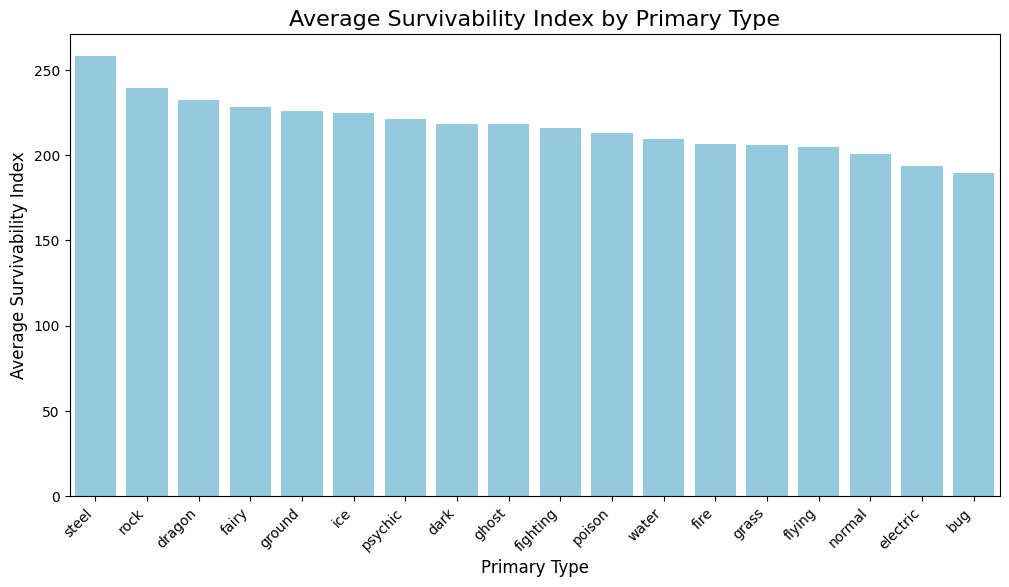

In [ ]:
# compute average survivability per primary type
survivability_by_type = pk_df.groupby('type1')['survivability_index'].mean().reset_index()

# sort by survivability descending
survivability_by_type = survivability_by_type.sort_values('survivability_index', ascending=False)

# plots the data
plt.figure(figsize=(12,6))
sns.barplot(data=survivability_by_type, x='type1', y='survivability_index', color='skyblue')

plt.title("Average Survivability Index by Primary Type", fontsize=16)
plt.xlabel("Primary Type", fontsize=12)
plt.ylabel("Average Survivability Index", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


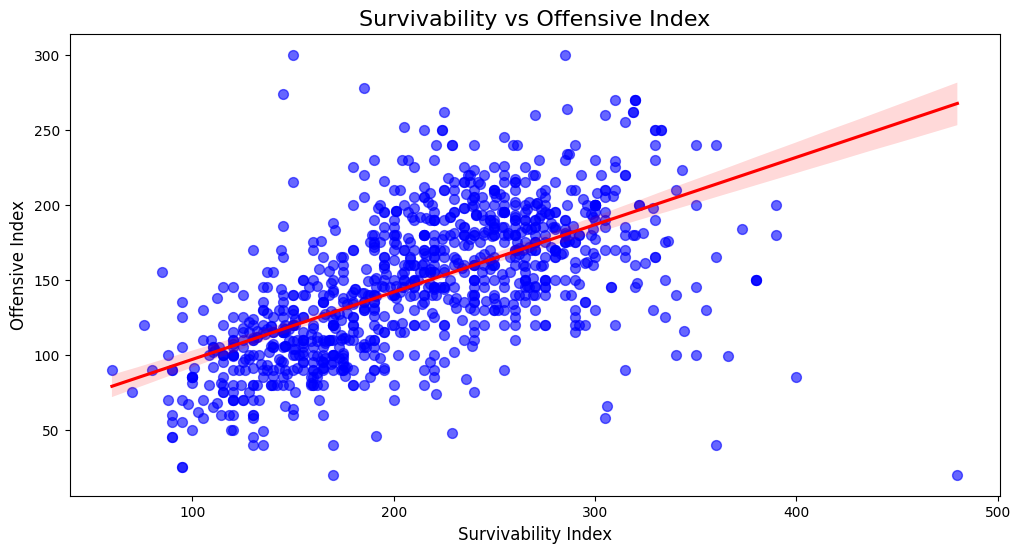

In [ ]:
# scatterplot with regression line
plt.figure(figsize=(12,6))
sns.regplot(data=pk_df, x='survivability_index', y='offensive_index', scatter_kws={'alpha':0.6, 's':50, 'color':'blue'}, line_kws={'color':'red'})

# plots survivability vs offensive index
# helps to visualized trade-offs between offense and defense
plt.title("Survivability vs Offensive Index", fontsize=16)
plt.ylabel("Offensive Index", fontsize=12)
plt.xlabel("Survivability Index", fontsize=12)
plt.show()

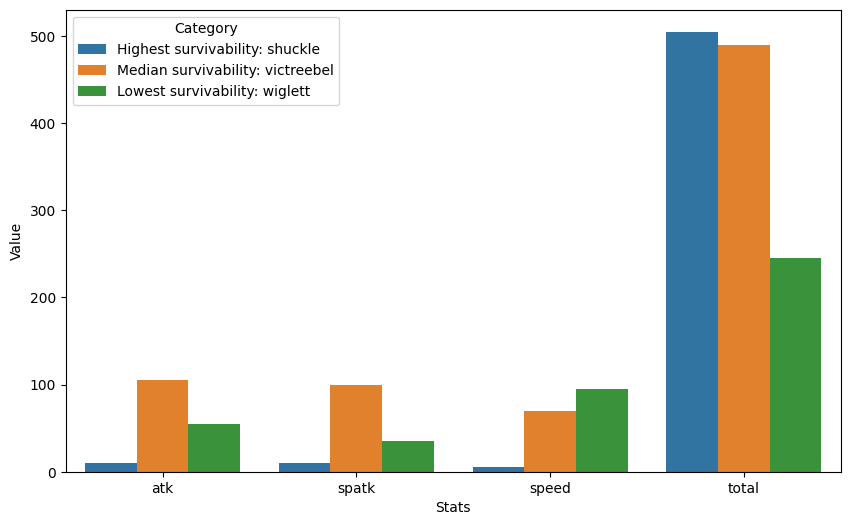

In [ ]:
# stats to include (exclude defensive stats since they're in survivability)
stats = ['atk','spatk','speed','total']

# selects the pokemon with the highest, median, and lowest survivability
most = pk_df.loc[pk_df['survivability_index'].idxmax()]
least = pk_df.loc[pk_df['survivability_index'].idxmin()]
median = pk_df.loc[(pk_df['survivability_index'] - pk_df['survivability_index'].median()).abs().idxmin()]

data = pd.DataFrame({
    'Stats': stats*3,
    'Value': list(most[stats]) + list(median[stats]) + list(least[stats]),
    'Category': [f"Highest survivability: {most['name']}"]*len(stats) + [f"Median survivability: {median['name']}"]*len(stats) + [f"Lowest survivability: {least['name']}"]*len(stats)
})

# graphs the data
# helps to visualize tradeoffs to see how having high survivability affects total power
plt.figure(figsize=(10,6))
sns.barplot(data=data, x='Stats', y='Value', hue='Category')
plt.show()

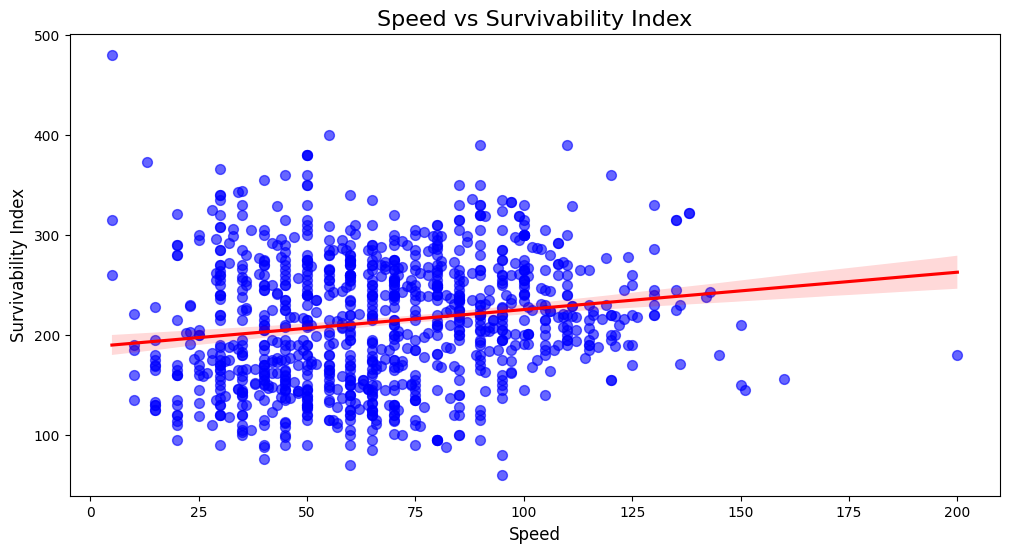

In [ ]:
# scatterplot with regression line
plt.figure(figsize=(12,6))
sns.regplot(data=pk_df, x='speed', y='survivability_index', scatter_kws={'alpha':0.6, 's':50, 'color':'blue'}, line_kws={'color':'red'})

# visualize the correlation of speed and survivability
# helps to see if survivability (generally associated with bulkiness because of hp and def) will negatively or positively affect speed
plt.title("Speed vs Survivability Index", fontsize=16)
plt.ylabel("Survivability Index", fontsize=12)
plt.xlabel("Speed", fontsize=12)
plt.show()

/tmp/ipython-input-2816654534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pk_df, x='is_legendary', y='survivability_index', palette=['skyblue','orange'])


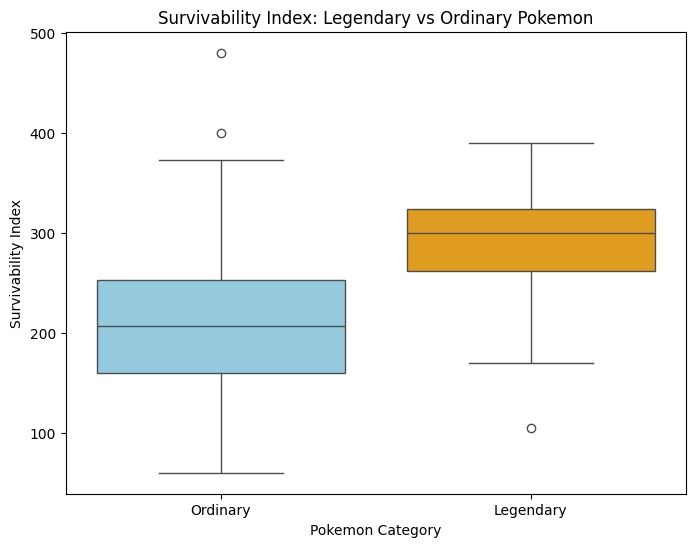

In [ ]:
# boxplot of legendary vs ordinary pokemon's survivability
plt.figure(figsize=(8,6))
sns.boxplot(data=pk_df, x='is_legendary', y='survivability_index', palette=['skyblue','orange'])

plt.xticks([0,1], ['Ordinary', 'Legendary'])
plt.title("Survivability Index: Legendary vs Ordinary Pokemon")
plt.ylabel("Survivability Index")
plt.xlabel("Pokemon Category")
plt.show()

# Power Creep Analysis

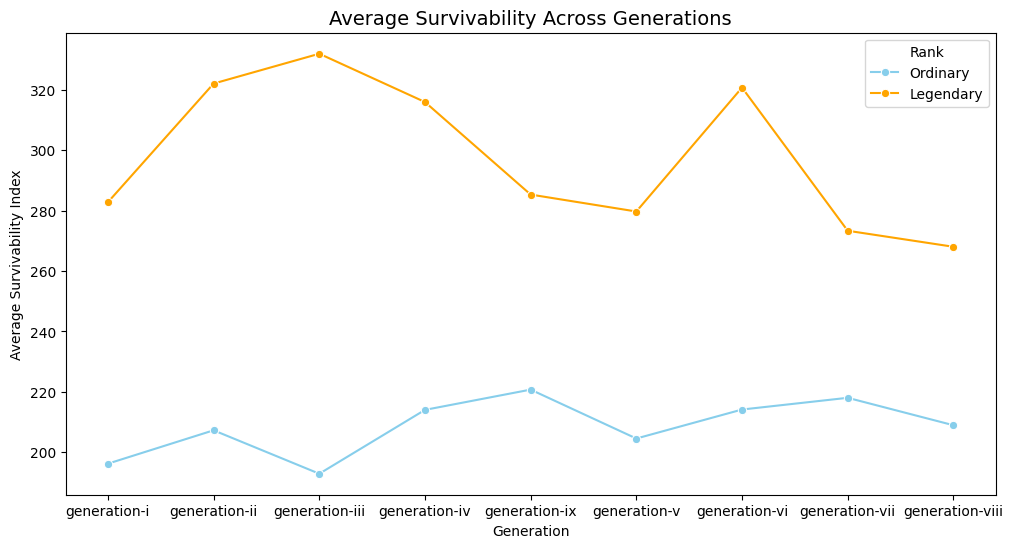

In [ ]:
# this graph focused on visualizing potential power creep in the survivability index
# in other words, whether or not survivability increased as the generations went on
avg_surv = pk_df.groupby(['generation', 'is_legendary'])['survivability_index'].mean().reset_index()

avg_surv['Rank'] = avg_surv['is_legendary'].replace({False:'Ordinary', True:'Legendary'})
# in the line plot ordinary and legendary pokemons were differentiated to see how stat inflation affected each individually
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_surv, x='generation', y='survivability_index', hue='Rank', marker='o', palette=['skyblue','orange'])
plt.title("Average Survivability Across Generations", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Average Survivability Index")
plt.show()

AI Assitance Log:
We used AI to organize the research paper and for basic syntax for the code. We verified that the responses were correct by testing the basic syntax it gave us on our specific project.